In [108]:
import os
import io
import csv
import tarfile
import math
import random
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from astropy.table import Table
from astropy.cosmology import Planck18
import astropy.units as u

import sncosmo

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ============================================================
# TOP-LEVEL CONTROLS
# ============================================================
N_LIGHTCURVES = 10          # set small first, then crank toward 1_000_000
OUTPUT_DIR = Path("sim_lcs")
OUTPUT_TARBALL = Path("sim_lcs.tar.gz")
RNG_SEED = 42

from pathlib import Path
import tarfile
import io
import math
import time
import pandas as pd

# ============================================================
# LARGE RUN CONFIG
# ============================================================
N_LIGHTCURVES = 100

OUTPUT_ROOT = Path("roman_jwst_sim")
CHUNK_SIZE = 10   # good starting point; 5k-20k is reasonable
COMPRESSLEVEL = 3    # faster than max compression

WRITE_PLAIN_CSVS = False   # absolutely leave this False for the large run
MAKE_MASTER_TARBALL = False  # set True only if you really want one final archive

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# split roughly equally
FRACTION_SNIA = 1/3
FRACTION_SNII = 1/3
FRACTION_SNIBC = 1/3

# redshift range
Z_MIN = 0.5
Z_MAX = 3.0

# Random peak-time range (observer-frame MJD-ish; arbitrary unless you care)
T0_MIN = 0.0
T0_MAX = 2000.0

# Require at least one point above this threshold somewhere in the final LC
MIN_REQUIRED_SNR = 5.0

# Retry limit so we don't loop forever on hard-to-detect objects
MAX_SIM_RETRIES = 5

# Roman HLTDS-like cadence: ~5 days
ROMAN_CADENCE_DAYS = 5.0

# Observation window relative to peak (rest-frame-ish buffer through z)
# Large enough that we can capture first/last non-detections robustly.
ROMAN_TMIN = -45.0
ROMAN_TMAX = 120.0

# JWST observations: random integer in [3, 8]
JWST_MIN_EPOCHS = 3
JWST_MAX_EPOCHS = 8

# Use AB system everywhere
ZP = 25.0
ZPSYS = "ab"

# Detection threshold for "upper_limit" and flag logic
SNR_DET_THRESHOLD = 3.0

# Tarball write mode
COMPRESSLEVEL = 3

# Whether to also leave plain CSV files on disk.
# Set False when scaling up to millions.
WRITE_PLAIN_CSVS = False

# Roman bands: union of currently described HLTDS imaging bands
ROMAN_BANDS = ["F062", "F087", "F106", "F129", "F158", "F184"]

# JWST bands requested
JWST_BANDS = ["F115W", "F150W", "F200W", "F277W", "F356W"]

# Approximate single-visit 5-sigma limiting mags (AB) -- tune these if desired.
# These are placeholders chosen to be realistic-ish, not ETC truth.
ROMAN_LIMMAG_5SIG = {
    "F062": 26.6,
    "F087": 26.7,
    "F106": 26.8,
    "F129": 26.8,
    "F158": 26.7,
    "F184": 26.3,
}

JWST_LIMMAG_5SIG = {
    "F115W": 28.5,
    "F150W": 28.5,
    "F200W": 28.5,
    "F277W": 28.5,
    "F356W": 28.5,
    "F444W": 28.5,
}

# Small per-visit scatter in limiting depth
ROMAN_LIMMAG_SCATTER = 0.10
JWST_LIMMAG_SCATTER = 0.10

# Register Roman / JWST bandpasses if not already present in sncosmo.
# These names depend on your local sncosmo bandpass cache / plugins.
# If your setup uses different names, edit BAND_NAME_MAP below.
#
# Try these direct names first; if your install differs, update mappings.
BAND_NAME_MAP = {
    "F062": "f062",
    "F087": "f087",
    "F106": "f106",
    "F129": "f129",
    "F158": "f158",
    "F184": "f184",
    "F115W": "f115w",
    "F150W": "f150w",
    "F200W": "f200w",
    "F277W": "f277w",
    "F356W": "f356w",
    "F444W": "f444w",
}

rng = np.random.default_rng(RNG_SEED)
random.seed(RNG_SEED)

OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

In [109]:
# ============================================================
# HELPERS
# ============================================================

def generate_chunk_tarball(
    chunk_index,
    sn_types,
    output_root=OUTPUT_ROOT,
    compresslevel=COMPRESSLEVEL,
):
    """
    Generate one tarball chunk containing a batch of simulated light curves.
    Returns the per-chunk manifest dataframe.
    """
    chunk_dir = output_root / "chunks"
    chunk_dir.mkdir(parents=True, exist_ok=True)

    tar_path = chunk_dir / f"lightcurves_chunk_{chunk_index:05d}.tar.gz"

    manifest_rows = []
    n_success = 0
    n_fail = 0

    t_start = time.time()

    with tarfile.open(tar_path, mode="w:gz", compresslevel=compresslevel) as tar:
        for global_id, sn_type in sn_types:
            try:
                df, meta = generate_single_sn(sn_type, global_id)

                snid = df["snid"].iloc[0]
                member_name = f"{sn_type}/{snid}.csv"

                write_df_to_tar(tar, df, member_name)

                manifest_rows.append({
                    "snid": snid,
                    "type": sn_type,
                    "z": meta["z"],
                    "t0": meta["t0"],
                    "hostebv": meta["hostebv"],
                    "hostr_v": meta["hostr_v"],
                    "M_peak_approx": meta["M_peak_approx"],
                    "n_rows": len(df),
                    "tar_member": member_name,
                    "chunk_index": chunk_index,
                    "global_id": global_id,
                })

                n_success += 1

            except Exception as e:
                manifest_rows.append({
                    "snid": f"{sn_type}_{global_id}",
                    "type": sn_type,
                    "z": None,
                    "t0": None,
                    "hostebv": None,
                    "hostr_v": None,
                    "M_peak_approx": None,
                    "n_rows": 0,
                    "tar_member": None,
                    "chunk_index": chunk_index,
                    "global_id": global_id,
                    "error": str(e),
                })
                n_fail += 1

        manifest_df = pd.DataFrame(manifest_rows)
        write_manifest_to_tar(tar, manifest_df, member_name="manifest.csv")

    dt = time.time() - t_start
    print(
        f"Chunk {chunk_index:05d} done | "
        f"success={n_success} fail={n_fail} | "
        f"time={dt/60:.1f} min | {tar_path}"
    )

    # Also save manifest outside tar for convenience
    manifest_path = chunk_dir / f"manifest_chunk_{chunk_index:05d}.csv"
    manifest_df.to_csv(manifest_path, index=False)

    return manifest_df
def generate_large_sample(
    n_total=N_LIGHTCURVES,
    chunk_size=CHUNK_SIZE,
    output_root=OUTPUT_ROOT,
    shuffle_types=True,
):
    """
    Generate the full large sample as chunked tarballs.
    """
    output_root.mkdir(parents=True, exist_ok=True)

    type_sequence = build_type_sequence(n_total, shuffle=shuffle_types)
    n_chunks = math.ceil(n_total / chunk_size)

    print(f"Generating {n_total:,} total light curves")
    print(f"Chunk size: {chunk_size:,}")
    print(f"Number of chunks: {n_chunks:,}")

    all_manifest_paths = []

    for chunk_index in range(n_chunks):
        start = chunk_index * chunk_size
        stop = min((chunk_index + 1) * chunk_size, n_total)

        chunk_sn_types = [
            (global_id, type_sequence[global_id])
            for global_id in range(start, stop)
        ]

        manifest_df = generate_chunk_tarball(
            chunk_index=chunk_index,
            sn_types=chunk_sn_types,
            output_root=output_root,
        )

        manifest_path = output_root / "chunks" / f"manifest_chunk_{chunk_index:05d}.csv"
        all_manifest_paths.append(manifest_path)

    # Combine all manifests into one master manifest
    master_manifest = pd.concat(
        [pd.read_csv(p) for p in all_manifest_paths],
        ignore_index=True
    )

    master_manifest_path = output_root / "master_manifest.csv"
    master_manifest.to_csv(master_manifest_path, index=False)

    print(f"\nDone.")
    print(f"Master manifest written to: {master_manifest_path}")

    success_mask = master_manifest["tar_member"].notna()
    print(f"Successful light curves: {success_mask.sum():,}")
    print(f"Failed light curves: {(~success_mask).sum():,}")

    return master_manifest
    
def counts_for_total(n_total):
    n_snia = n_total // 3
    n_sn2 = n_total // 3
    n_snibc = n_total - n_snia - n_sn2
    return n_snia, n_sn2, n_snibc


def build_type_sequence(n_total, shuffle=True):
    """
    Construct roughly equal subtype labels for the whole run.
    """
    n_snia, n_sn2, n_snibc = counts_for_total(n_total)
    seq = (
        ["snia"] * n_snia +
        ["sn2"] * n_sn2 +
        ["snibc"] * n_snibc
    )
    if shuffle:
        rng.shuffle(seq)
    return seq


def write_df_to_tar(tar, df, member_name):
    csv_bytes = df.to_csv(index=False).encode("utf-8")
    bio = io.BytesIO(csv_bytes)
    info = tarfile.TarInfo(name=member_name)
    info.size = len(csv_bytes)
    tar.addfile(tarinfo=info, fileobj=bio)


def write_manifest_to_tar(tar, manifest_df, member_name="manifest.csv"):
    csv_bytes = manifest_df.to_csv(index=False).encode("utf-8")
    bio = io.BytesIO(csv_bytes)
    info = tarfile.TarInfo(name=member_name)
    info.size = len(csv_bytes)
    tar.addfile(tarinfo=info, fileobj=bio)
    
def band_supported_by_model(model, band_name, times):
    """
    Return True if the model can be evaluated for this band at at least one time.
    If the band lies outside the source/model wavelength range, return False.
    """
    times = np.atleast_1d(times)

    try:
        vals = model.bandflux(band_name, times, zp=ZP, zpsys=ZPSYS)
        vals = np.asarray(vals, dtype=float)
        return np.any(np.isfinite(vals))
    except Exception:
        return False


def safe_bandmag(model, band_name, times):
    """
    Safe wrapper around model.bandmag. Returns NaNs if unsupported.
    """
    times = np.atleast_1d(times)
    try:
        vals = model.bandmag(band_name, "ab", times)
        vals = np.asarray(vals, dtype=float)
        return vals
    except Exception:
        return np.full(len(times), np.nan, dtype=float)
        
def mag_to_flux(mag, zp=ZP):
    """AB mag to sncosmo flux units for the chosen zp."""
    return 10 ** (-0.4 * (mag - zp))

def flux_to_mag(flux, zp=ZP):
    """sncosmo flux to mag; returns np.nan for non-positive flux."""
    flux = np.asarray(flux)
    out = np.full_like(flux, np.nan, dtype=float)
    m = flux > 0
    out[m] = zp - 2.5 * np.log10(flux[m])
    return out

def fluxerr_from_limmag(limmag_5sig, zp=ZP):
    """
    Convert 5-sigma limiting mag to 1-sigma flux uncertainty.
    """
    f5 = mag_to_flux(limmag_5sig, zp=zp)
    return f5 / 5.0

def distance_modulus(z):
    return Planck18.distmod(z).value

def sample_host_ebv(sn_type, size=None):
    """
    Simple positive distribution for host E(B-V), by subtype.
    These are pragmatic, not holy scripture.
    """
    if sn_type == "snia":
        # mostly low extinction, modest tail
        vals = rng.exponential(scale=0.08, size=size)
    elif sn_type == "sn2":
        vals = rng.exponential(scale=0.12, size=size)
    elif sn_type == "snibc":
        vals = rng.exponential(scale=0.18, size=size)
    else:
        vals = rng.exponential(scale=0.10, size=size)

    return np.clip(vals, 0.0, 0.8)

def sample_host_rv(size=None):
    # mild spread around MW-ish values
    vals = rng.normal(loc=3.1, scale=0.5, size=size)
    return np.clip(vals, 1.8, 4.5)

def sample_abs_mag(sn_type):
    """
    Crude peak absolute magnitude priors by type.
    These are used to set amplitudes approximately.
    """
    if sn_type == "snia":
        return rng.normal(-19.3, 0.25)
    elif sn_type == "sn2":
        # IIP
        return rng.normal(-16.7, 0.8)
    elif sn_type == "snibc":
        return rng.normal(-17.8, 0.9)
    else:
        raise ValueError(sn_type)

def get_model(sn_type):
    """
    Build a sncosmo model with F99 host dust.
    """
    if sn_type == "snia":
        source = "hsiao"
    elif sn_type == "sn2":
        source = "nugent-sn2p"
    elif sn_type == "snibc":
        source = "nugent-sn1bc"
    else:
        raise ValueError(sn_type)

    dust = sncosmo.F99Dust()
    model = sncosmo.Model(
        source=source,
        effects=[dust],
        effect_names=["host"],
        effect_frames=["rest"],
    )
    return model

def set_model_parameters(model, sn_type, z, t0):
    """
    Set SN parameters using sncosmo's built-in absolute magnitude scaling.
    Uses F99 host dust and realistic-ish subtype luminosity priors.
    """
    hostebv = float(sample_host_ebv(sn_type))
    hostrv = float(sample_host_rv())

    model.set(
        z=z,
        t0=t0,
        hostebv=hostebv,
        hostr_v=hostrv,
    )

    # Draw subtype-dependent absolute magnitude
    M_peak = sample_abs_mag(sn_type)

    # Use a stable rest-frame optical band for normalization
    # bessellb is usually a good generic choice across templates
    absmag_band = "bessellb"
    magsys = "ab"
    #try:
    model.set_source_peakabsmag(M_peak, absmag_band, magsys)
    #except Exception:
    #    # Rare template edge case fallback
    #    model.set_source_absmag(M_peak, "bessellv", magsys)
    #    absmag_band = "bessellv"

    return {
        "z": z,
        "t0": t0,
        "hostebv": hostebv,
        "hostr_v": hostrv,
        "M_peak_approx": M_peak,
        "absmag_band_used": absmag_band,
        "model":model
    }

def make_roman_schedule(t0):
    """
    Create a Roman cadence table:
    every 5 days, all HLTDS imaging bands each epoch.
    """
    times = np.arange(t0 + ROMAN_TMIN, t0 + ROMAN_TMAX + 0.1, ROMAN_CADENCE_DAYS)
    rows = []
    for t in times:
        for band in ROMAN_BANDS:
            rows.append((t, band))
    return rows
def has_minimum_band_coverage(obs, min_rows=5):
    return len(obs) >= min_rows
    
def make_jwst_schedule(t0):
    """
    Random 3-8 JWST epochs, biased toward useful phases.
    """
    n_epochs = rng.integers(JWST_MIN_EPOCHS, JWST_MAX_EPOCHS + 1)

    n1 = max(1, n_epochs // 2)
    n2 = n_epochs - n1

    phases = np.sort(np.concatenate([
        rng.uniform(-8.0, 15.0, size=n1),
        rng.uniform(15.0, 50.0, size=n2),
    ]))

    times = t0 + phases

    rows = []
    for t in times:
        for band in JWST_BANDS:
            rows.append((t, band))
    return rows

def noise_row_for_band(band):
    """
    Return skynoise and gain fields expected by sncosmo.
    gain is kept simple; skynoise is derived from approximate depth.
    """
    if band in ROMAN_LIMMAG_5SIG:
        limmag = rng.normal(ROMAN_LIMMAG_5SIG[band], ROMAN_LIMMAG_SCATTER)
    elif band in JWST_LIMMAG_5SIG:
        limmag = rng.normal(JWST_LIMMAG_5SIG[band], JWST_LIMMAG_SCATTER)
    else:
        raise KeyError(f"Unknown band {band}")

    ferr = fluxerr_from_limmag(limmag, zp=ZP)

    # sncosmo uses skynoise in same flux units
    # gain is not very important here; use a harmless constant.
    return dict(gain=1.0, skynoise=float(ferr), limmag_5sig=float(limmag))

def build_observation_table(model, t0):
    """
    Build Roman + JWST observation table, skipping unsupported bands.
    """
    rows = []

    roman_rows = make_roman_schedule(t0)
    jwst_rows = make_jwst_schedule(t0)

    all_rows = roman_rows + jwst_rows

    for t, short_band in all_rows:
        full_band = BAND_NAME_MAP[short_band]

        # Skip unsupported model/band combinations
        if not band_supported_by_model(model, full_band, [t]):
            continue

        nr = noise_row_for_band(short_band)
        rows.append((
            full_band,
            float(t),
            ZP,
            ZPSYS,
            nr["gain"],
            nr["skynoise"],
            short_band,
            nr["limmag_5sig"],
        ))

    if len(rows) == 0:
        raise RuntimeError("No supported observations for this SN after wavelength filtering.")

    obs = Table(
        rows=rows,
        names=["band", "time", "zp", "zpsys", "gain", "skynoise", "band_short", "limmag_5sig"]
    )
    obs.sort("time")
    return obs

def realize_lightcurve(model, obs):
    """
    Evaluate noiseless model fluxes directly with bandflux, then add Gaussian noise
    using the per-observation skynoise only.

    This avoids sncosmo.realize_lcs injecting extra Poisson noise through gain.
    Unsupported band/time combinations are skipped automatically.
    """
    rows = []

    for row in obs:
        band = row["band"]
        time = float(row["time"])
        zp = float(row["zp"])
        zpsys = row["zpsys"]
        sigma = np.sqrt(0.01**2 + float(row["skynoise"])**2)

        try:
            true_flux = float(model.bandflux(band, time, zp=zp, zpsys=zpsys))
        except Exception:
            # skip unsupported wavelength coverage etc.
            continue

        if not np.isfinite(true_flux):
            continue

        noisy_flux = true_flux + rng.normal(0.0, sigma)

        rows.append((
            band,
            time,
            noisy_flux,
            sigma,
            zp,
            zpsys,
            row["band_short"],
            row["limmag_5sig"],
            true_flux,
        ))

    if len(rows) == 0:
        raise RuntimeError("No valid observations after evaluating bandflux.")

    lc = Table(
        rows=rows,
        names=[
            "band", "time", "flux", "fluxerr", "zp", "zpsys",
            "band_short", "limmag_5sig", "true_flux"
        ]
    )
    lc.sort("time")
    return lc

def add_mag_columns(df):
    """
    Compute mag/magerr for positive-flux significant detections.
    For upper limits / bad fluxes, mag and magerr are NaN.
    """
    flux = df["flux"].to_numpy(dtype=float)
    fluxerr = df["fluxerr"].to_numpy(dtype=float)

    mag = np.full(len(df), np.nan)
    magerr = np.full(len(df), np.nan)

    good = (flux > 0) & np.isfinite(flux) & np.isfinite(fluxerr) & (fluxerr > 0)
    mag[good] = ZP - 2.5 * np.log10(flux[good])
    magerr[good] = 1.0857362047581294 * fluxerr[good] / flux[good]

    df["mag"] = mag
    df["magerr"] = magerr
    return df

def keep_first_last_nondetections(df):
    """
    Keep:
      - all JWST points
      - all Roman detections
      - exactly one Roman non-detection before the first Roman detection
      - exactly one Roman non-detection after the last Roman detection

    This implements the "include first and last non-detection" request.
    """
    is_roman = df["band"].isin(ROMAN_BANDS)
    roman = df[is_roman].sort_values("time").copy()
    other = df[~is_roman].copy()

    roman_det = roman["upper_limit"] == 0

    if roman_det.sum() == 0:
        # No Roman detections at all: keep everything so we don't silently drop the SN.
        out = pd.concat([roman, other], ignore_index=True).sort_values("time")
        return out

    first_det_idx = np.where(roman_det.to_numpy())[0][0]
    last_det_idx = np.where(roman_det.to_numpy())[0][-1]

    keep = np.zeros(len(roman), dtype=bool)
    keep[roman_det.to_numpy()] = True

    # first non-detection before first detection
    prev_non = np.where(~roman_det.to_numpy()[:first_det_idx])[0]
    if len(prev_non) > 0:
        keep[prev_non[-1]] = True

    # last non-detection after last detection
    next_non = np.where(~roman_det.to_numpy()[last_det_idx + 1:])[0]
    if len(next_non) > 0:
        keep[last_det_idx + 1 + next_non[0]] = True

    roman_kept = roman.iloc[keep]
    out = pd.concat([roman_kept, other], ignore_index=True).sort_values("time")
    return out

def tidy_output(df, snid, z):
    """
    Produce final required columns:
    band flux fluxerr zp zpsys time mag magerr upper_limit snid z flag
    """
    df = df.copy()

    # use short human-facing band names in output
    if "band_short" in df.columns:
        df["band"] = df["band_short"]

    snr = np.abs(df["flux"] / df["fluxerr"])
    df["upper_limit"] = (snr < SNR_DET_THRESHOLD).astype(int)
    df["flag"] = np.where(snr >= SNR_DET_THRESHOLD, 4096, 0)

    df = add_mag_columns(df)
    df["snid"] = snid
    df["z"] = z

    # clean column order
    cols = [
        "band", "flux", "fluxerr", "zp", "zpsys", "time",
        "mag", "magerr", "upper_limit", "snid", "z", "flag"
    ]
    return df[cols]

def generate_single_sn(sn_type, unique_id, max_retries=MAX_SIM_RETRIES):
    for attempt in range(max_retries):
        z = float(rng.uniform(Z_MIN, Z_MAX))
        t0 = float(rng.uniform(T0_MIN, T0_MAX))

        model = get_model(sn_type)
        meta = set_model_parameters(model, sn_type, z, t0)

        obs = build_observation_table(model, t0)
        lc = realize_lightcurve(model, obs)

        df = lc.to_pandas()

        required = {"band", "time", "flux", "fluxerr", "zp", "zpsys"}
        missing = required - set(df.columns)
        if missing:
            raise RuntimeError(f"Missing columns in realized light curve: {missing}")

        df = tidy_output(
            df=df,
            snid=f"{sn_type}_{unique_id}",
            z=z,
        )

        df = keep_first_last_nondetections(df)
        df = df.sort_values(["time", "band"]).reset_index(drop=True)

        if max_snr(df) >= MIN_REQUIRED_SNR:
            return df, meta

    raise RuntimeError(
        f"Failed to generate acceptable {sn_type}_{unique_id} after {max_retries} retries"
    )

def write_df_to_tar(tar, df, member_name):
    csv_bytes = df.to_csv(index=False).encode("utf-8")
    bio = io.BytesIO(csv_bytes)
    info = tarfile.TarInfo(name=member_name)
    info.size = len(csv_bytes)
    tar.addfile(tarinfo=info, fileobj=bio)

def counts_for_total(n_total):
    n_snia = int(round(n_total * FRACTION_SNIA))
    n_sn2 = int(round(n_total * FRACTION_SNII))
    n_snibc = n_total - n_snia - n_sn2
    return n_snia, n_sn2, n_snibc

def max_snr(df):
    snr = np.abs(df["flux"].to_numpy(dtype=float) / df["fluxerr"].to_numpy(dtype=float))
    snr = snr[np.isfinite(snr)]
    if len(snr) == 0:
        return -np.inf
    return np.max(snr)

In [66]:
# ============================================================
# OPTIONAL SANITY CHECK
# ============================================================
# This will tell you early if your local sncosmo install doesn't recognize
# the Roman/JWST band names in BAND_NAME_MAP.

for short_name, band_name in BAND_NAME_MAP.items():
    try:
        _ = sncosmo.get_bandpass(band_name)
        print(f"OK  {short_name:>5s} -> {band_name}")
    except Exception as e:
        print(f"BAD {short_name:>5s} -> {band_name}    ({e})")

OK   F062 -> f062
OK   F087 -> f087
OK   F106 -> f106
OK   F129 -> f129
OK   F158 -> f158
OK   F184 -> f184
OK  F115W -> f115w
OK  F150W -> f150w
OK  F200W -> f200w
OK  F277W -> f277w
OK  F356W -> f356w
OK  F444W -> f444w


Test split: 4 4 4
snia {'z': 0.694421168842436, 't0': 1604.9850576886827, 'hostebv': 0.09806506753911703, 'hostr_v': 2.3382733292872517, 'M_peak_approx': -19.479456128507138, 'absmag_band_used': 'bessellb', 'model': <sncosmo.models.Model object at 0x7fd5e80997b0>}


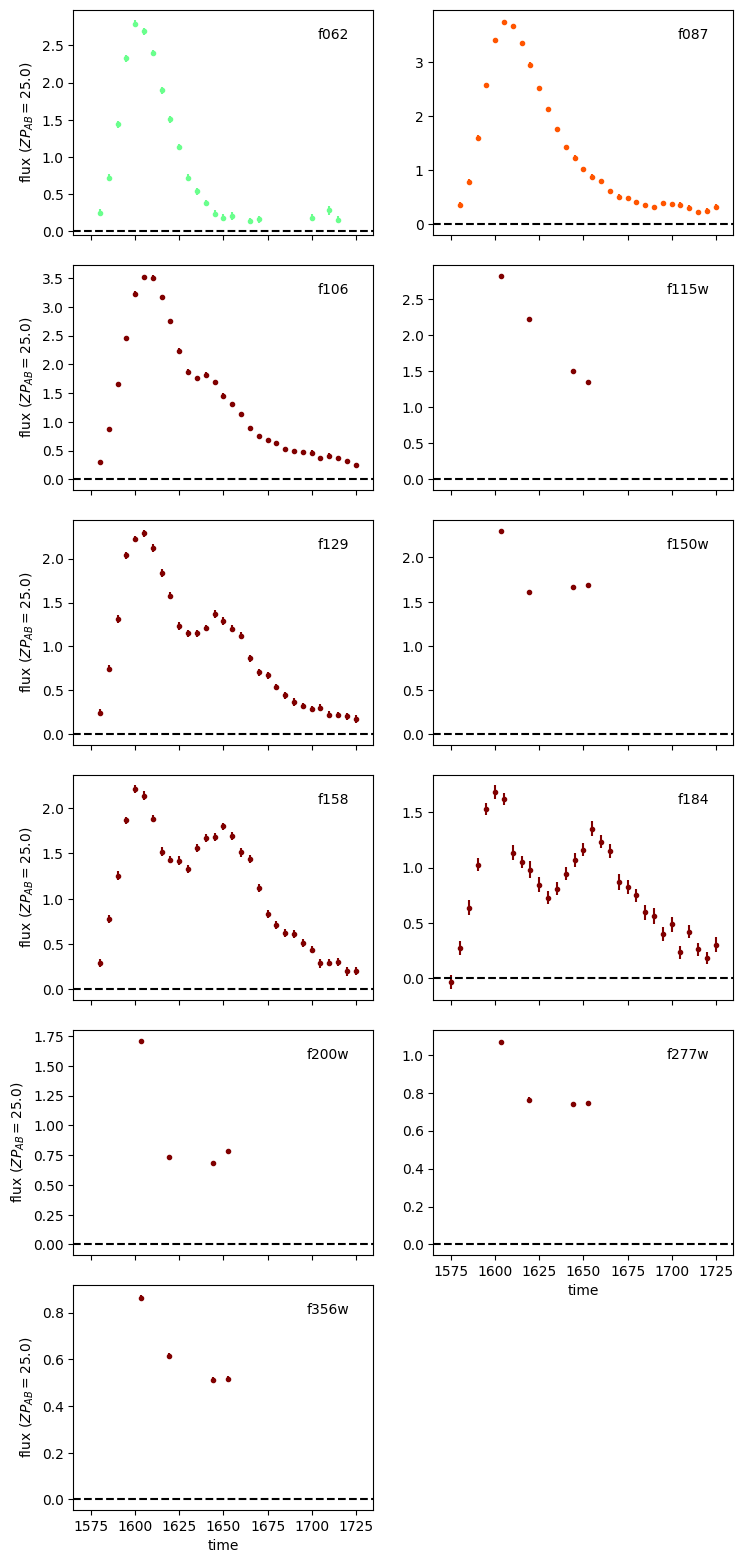

snia {'z': 1.1527764350210983, 't0': 788.7976928423927, 'hostebv': 0.09166203955100134, 'hostr_v': 2.8864185763419434, 'M_peak_approx': -19.250423780382985, 'absmag_band_used': 'bessellb', 'model': <sncosmo.models.Model object at 0x7fd6104153c0>}


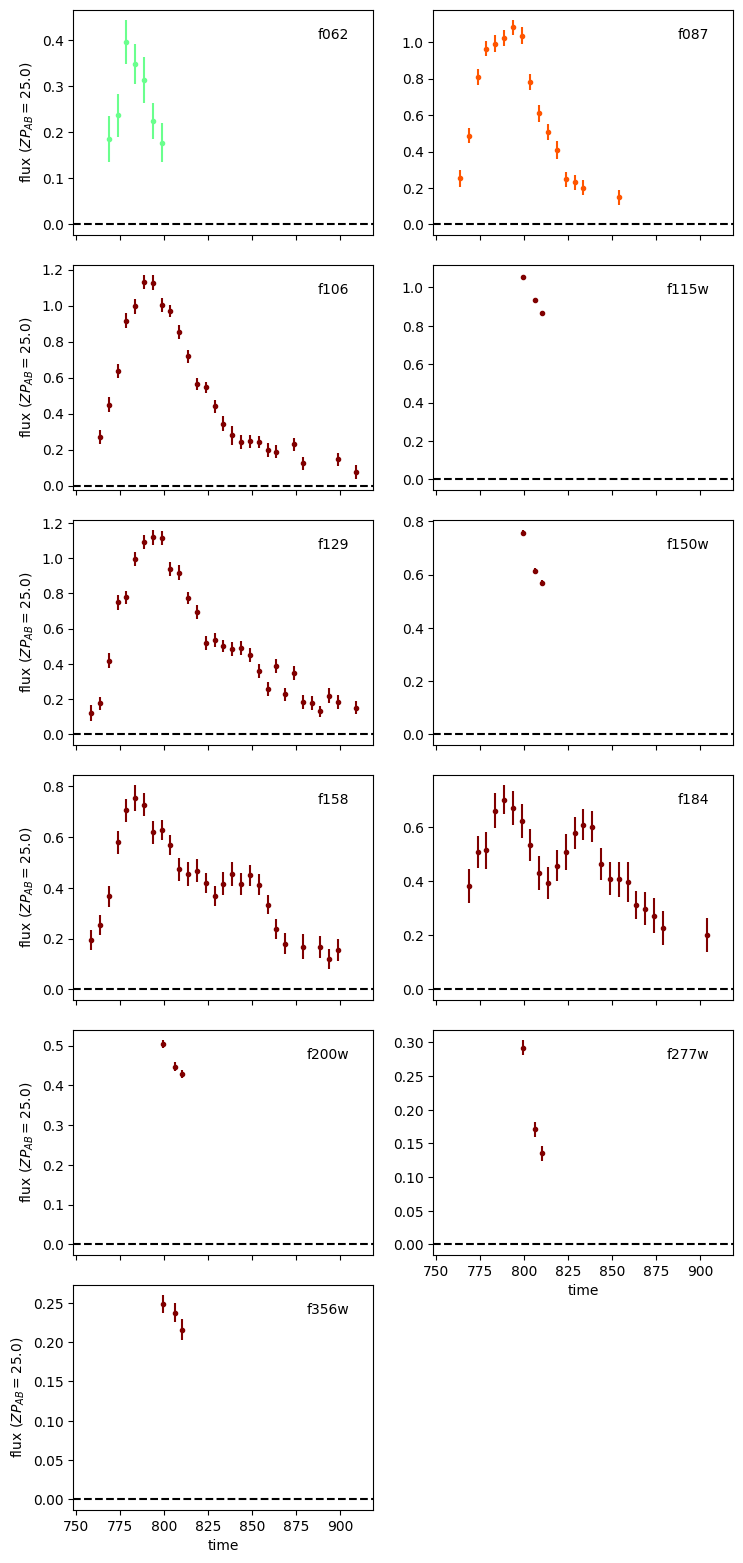

snia {'z': 1.5711004260132433, 't0': 74.29676902033644, 'hostebv': 0.15923946725405838, 'hostr_v': 2.7641002029351505, 'M_peak_approx': -19.118009884610604, 'absmag_band_used': 'bessellb', 'model': <sncosmo.models.Model object at 0x7fd609a57eb0>}


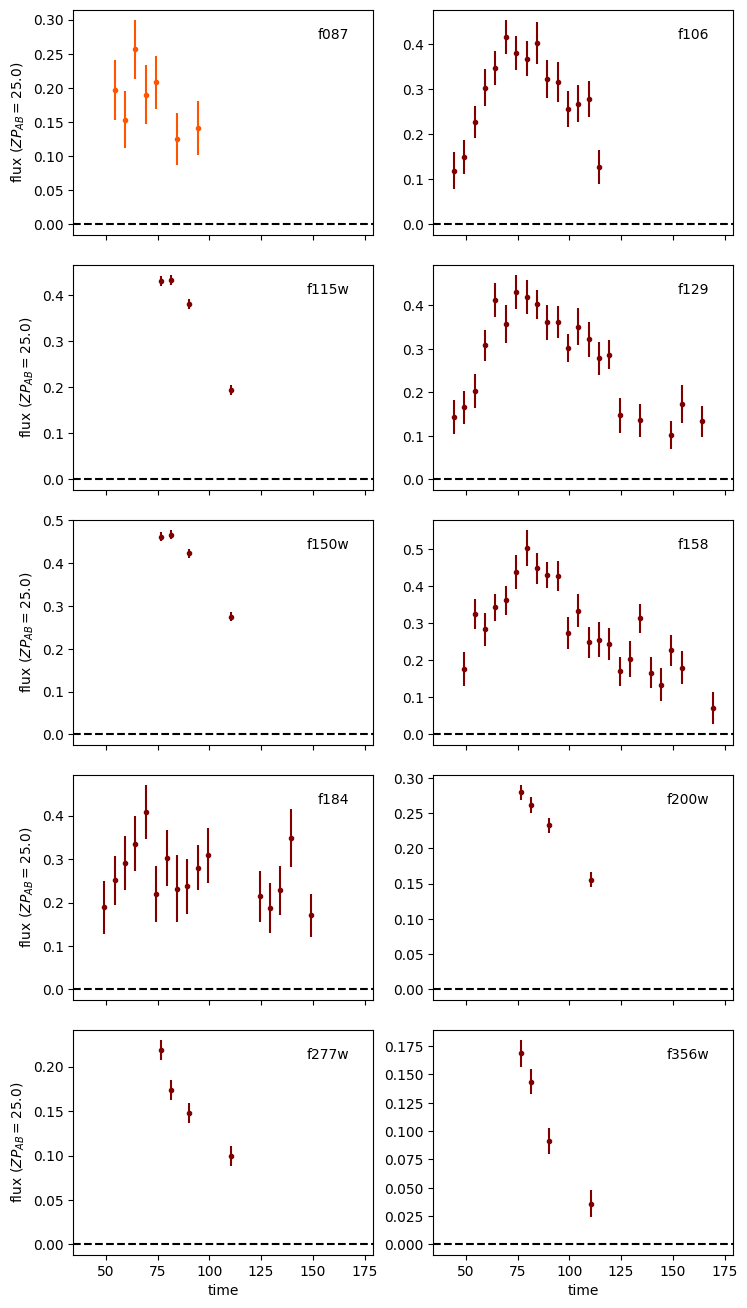

snia {'z': 2.5346897487862035, 't0': 365.784460552536, 'hostebv': 0.1027601947887065, 'hostr_v': 3.901236482143923, 'M_peak_approx': -19.379550598247487, 'absmag_band_used': 'bessellb', 'model': <sncosmo.models.Model object at 0x7fd64a867040>}


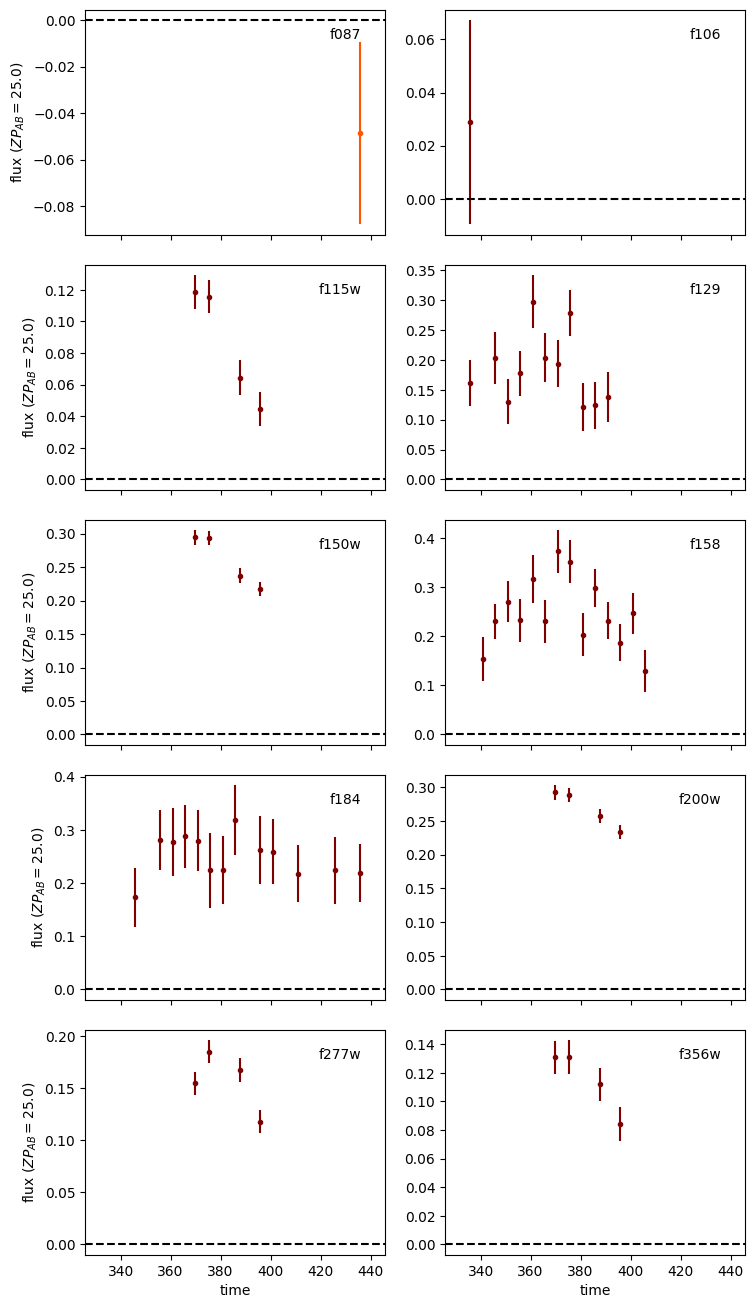

sn2 {'z': 0.8925833207341147, 't0': 920.444169635419, 'hostebv': 0.01719287263408933, 'hostr_v': 2.149282707818534, 'M_peak_approx': -16.390931119728688, 'absmag_band_used': 'bessellb', 'model': <sncosmo.models.Model object at 0x7fd5e80b8ca0>}


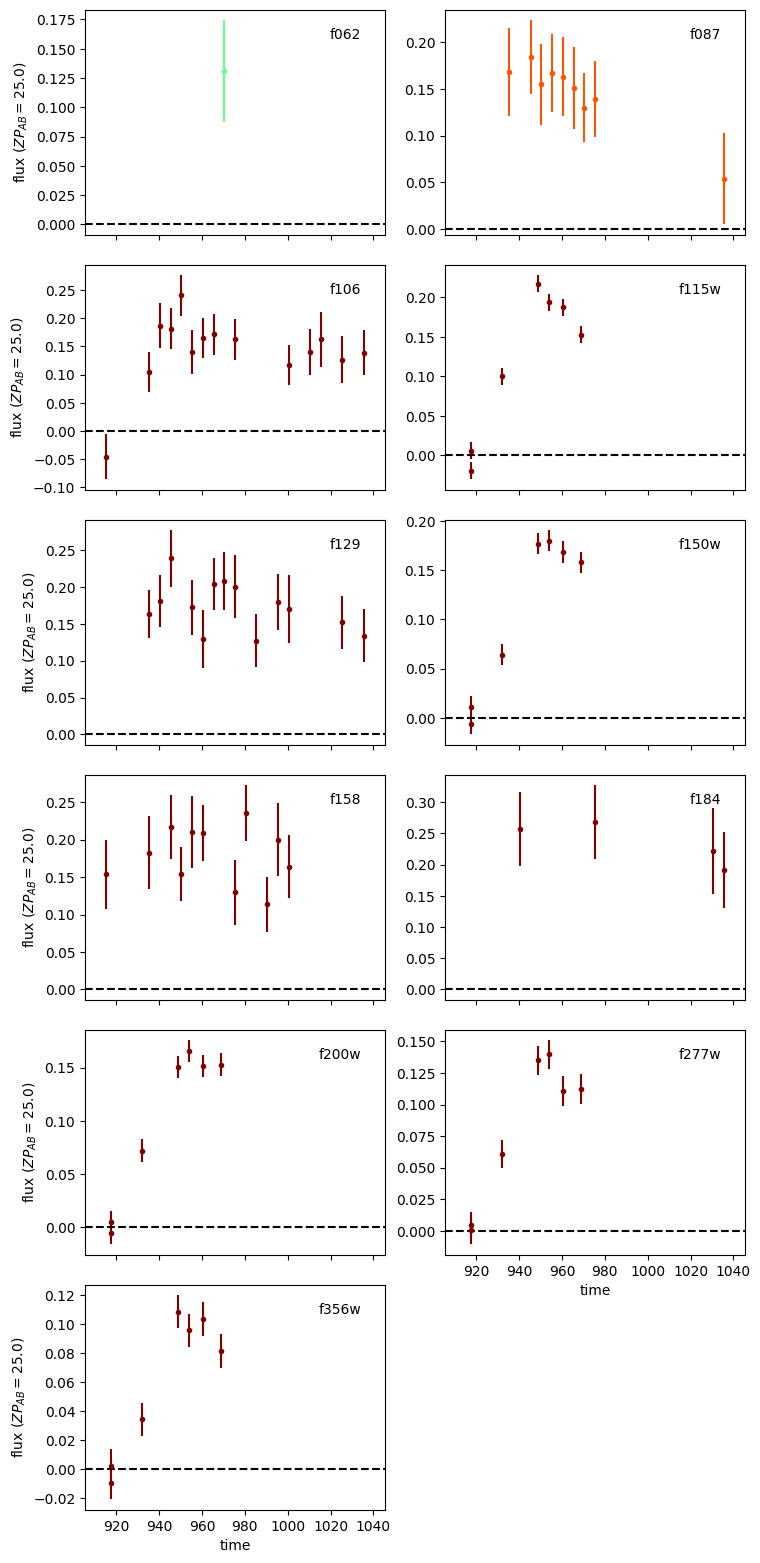

sn2 {'z': 1.0404699784669322, 't0': 485.2265036933747, 'hostebv': 0.06148025921494334, 'hostr_v': 2.255950059522381, 'M_peak_approx': -17.162080513678518, 'absmag_band_used': 'bessellb', 'model': <sncosmo.models.Model object at 0x7fd61a82b070>}


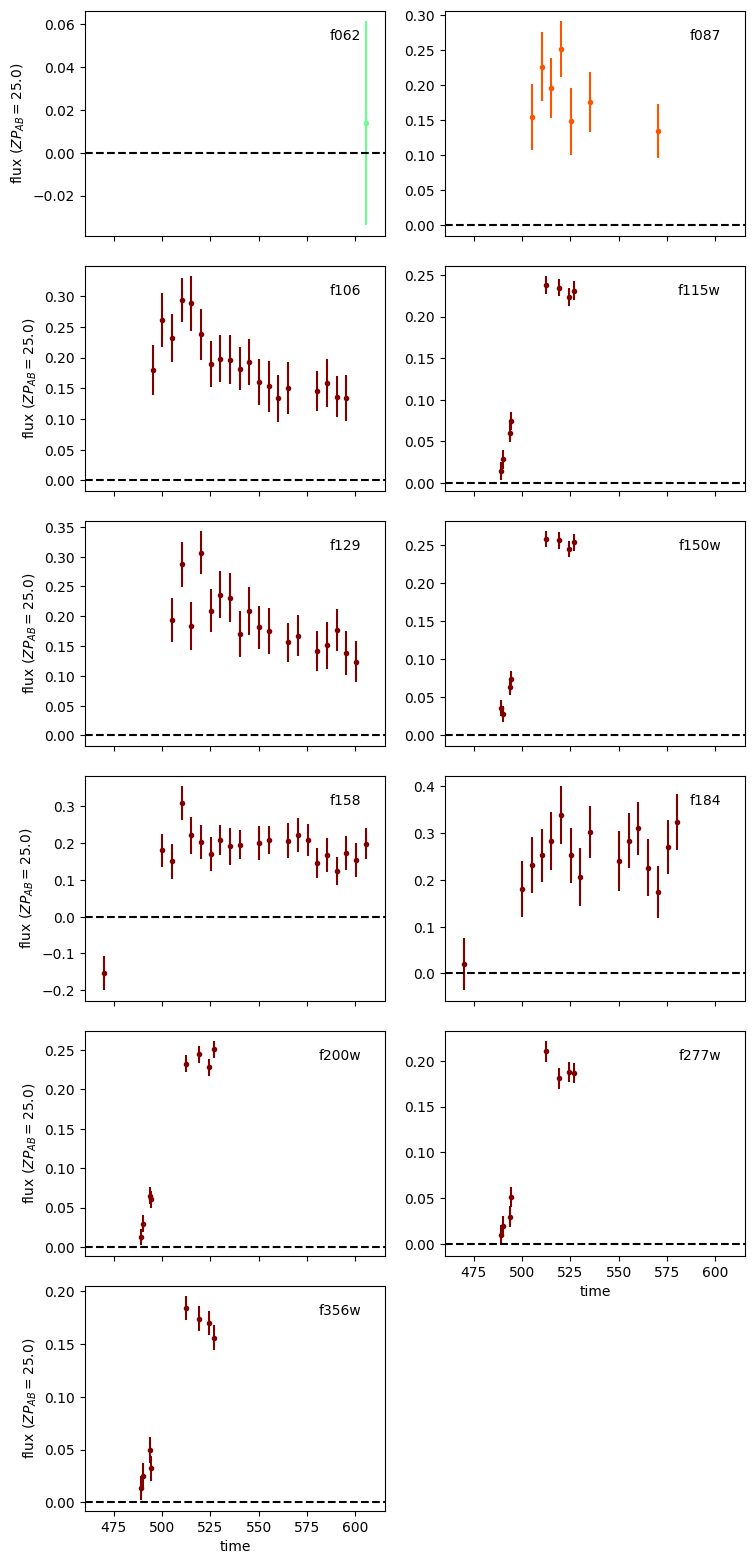

sn2 {'z': 1.5331416967844471, 't0': 66.07842353742433, 'hostebv': 0.013637425938368268, 'hostr_v': 3.3758688275456152, 'M_peak_approx': -16.543983507536897, 'absmag_band_used': 'bessellb', 'model': <sncosmo.models.Model object at 0x7fd64a1d9f90>}


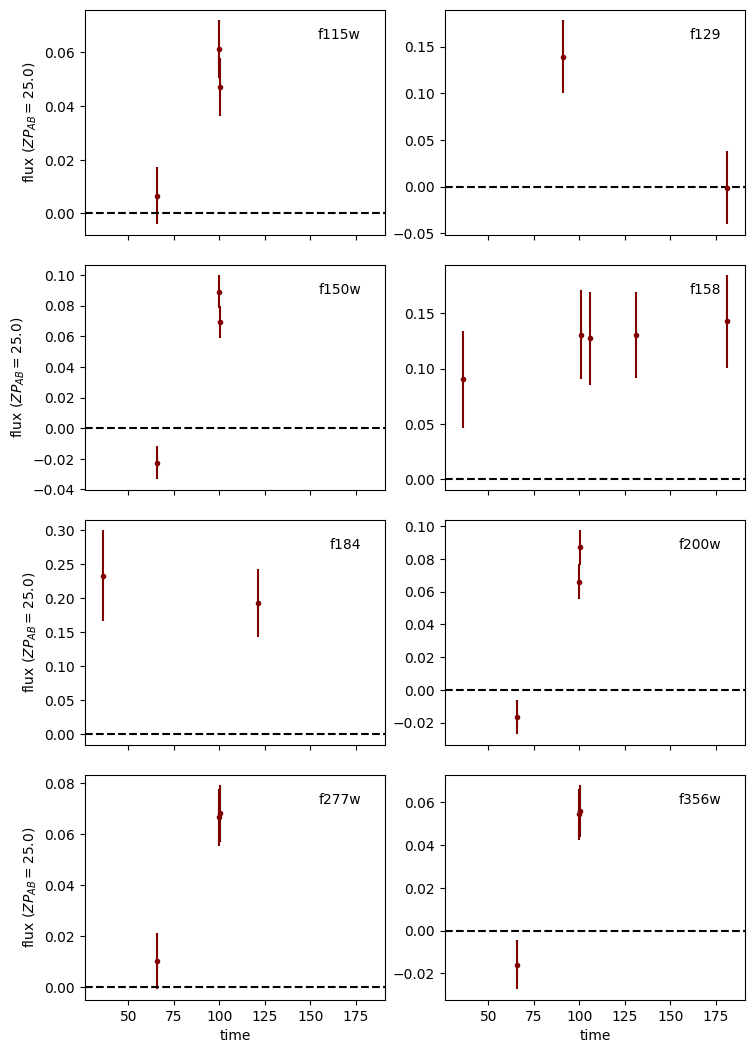

sn2 {'z': 2.2807864115084824, 't0': 1980.9950278987535, 'hostebv': 0.003591868615654555, 'hostr_v': 4.394413787093841, 'M_peak_approx': -17.405174163125164, 'absmag_band_used': 'bessellb', 'model': <sncosmo.models.Model object at 0x7fd61a840070>}


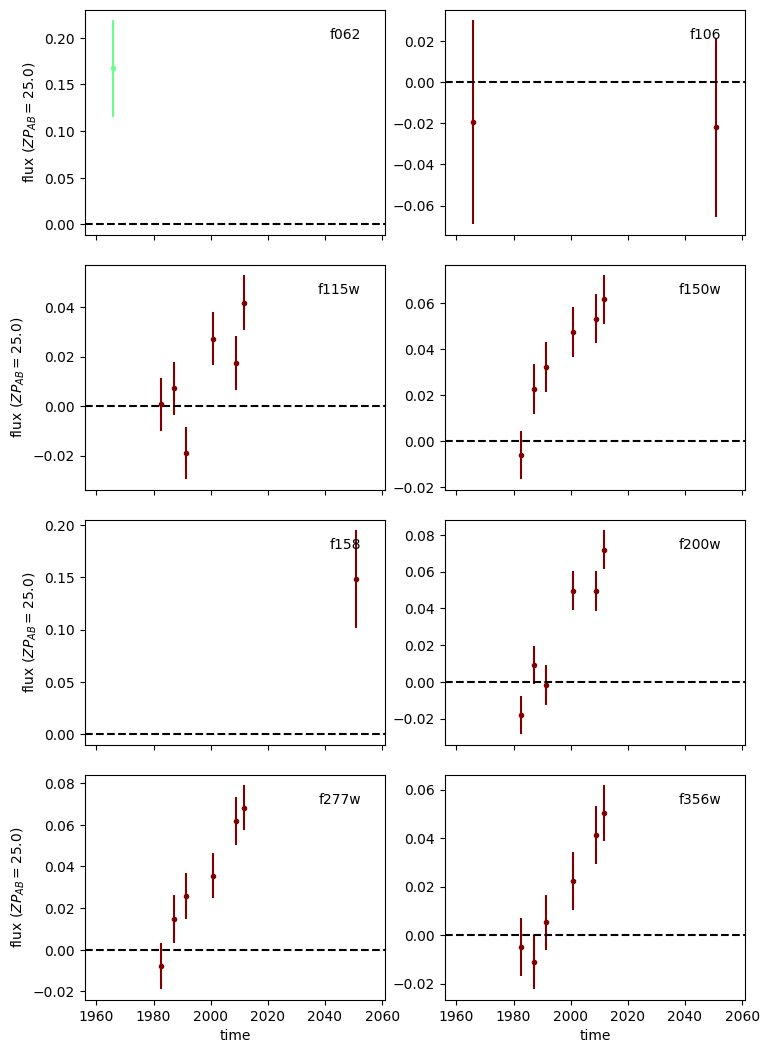

snibc {'z': 0.5109780089478811, 't0': 1049.00483608954, 'hostebv': 0.17573721725745312, 'hostr_v': 3.393522503012514, 'M_peak_approx': -17.161825899537867, 'absmag_band_used': 'bessellb', 'model': <sncosmo.models.Model object at 0x7fd61a43a860>}


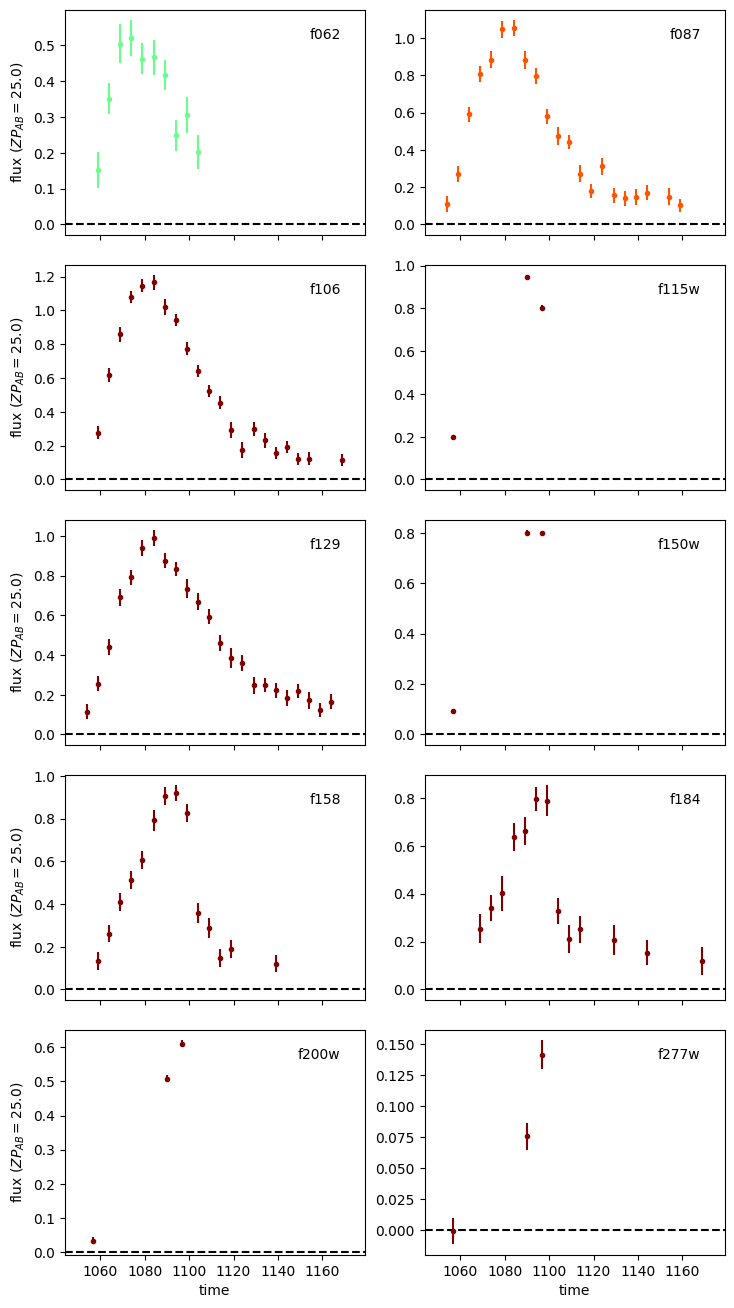

snibc {'z': 0.892182886740349, 't0': 1535.3802486605123, 'hostebv': 0.039383269738389355, 'hostr_v': 3.561665512241116, 'M_peak_approx': -16.190127339935284, 'absmag_band_used': 'bessellb', 'model': <sncosmo.models.Model object at 0x7fd61a329c60>}


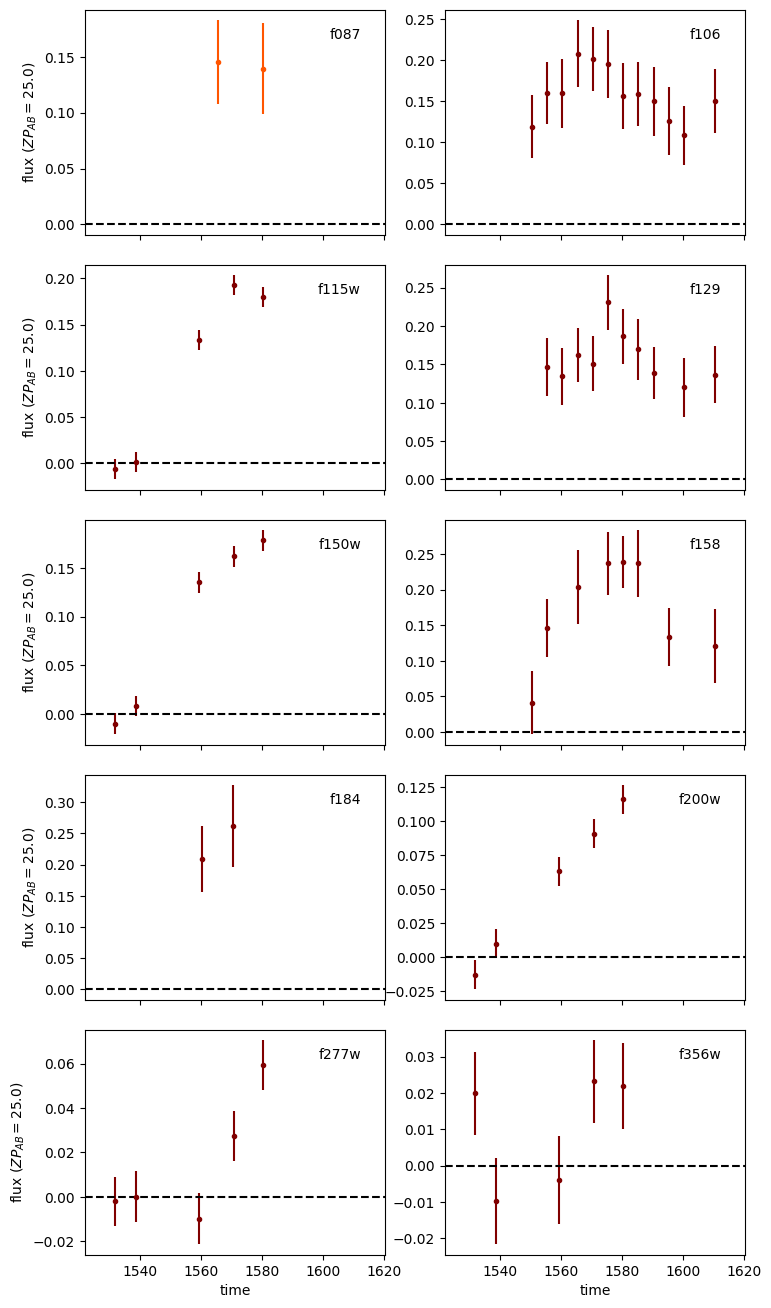

snibc {'z': 2.0653806094024674, 't0': 545.3590445665773, 'hostebv': 0.18019770891727568, 'hostr_v': 3.210969584188222, 'M_peak_approx': -18.4901695019005, 'absmag_band_used': 'bessellb', 'model': <sncosmo.models.Model object at 0x7fd649ef1ab0>}


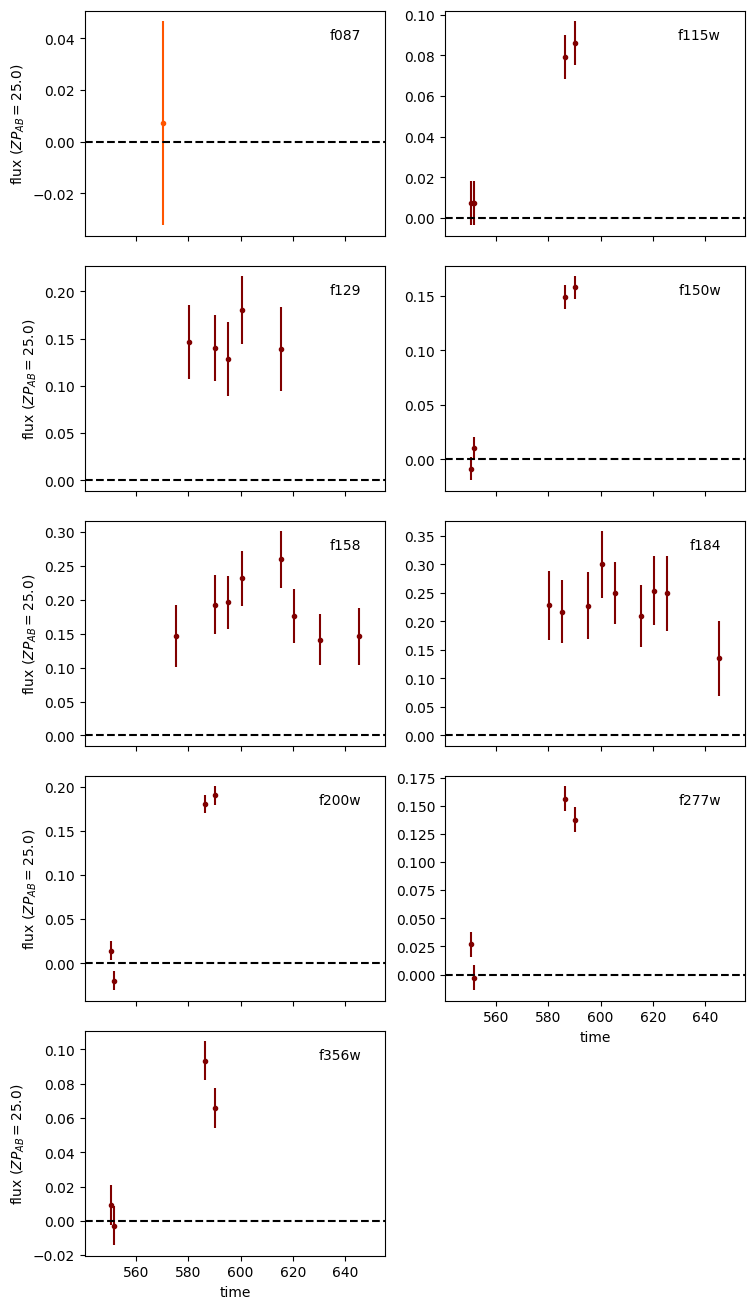

snibc {'z': 0.842021067469459, 't0': 537.2789866676698, 'hostebv': 0.4631406045722852, 'hostr_v': 2.7332424094709586, 'M_peak_approx': -19.34624453743617, 'absmag_band_used': 'bessellb', 'model': <sncosmo.models.Model object at 0x7fd6304ca7a0>}


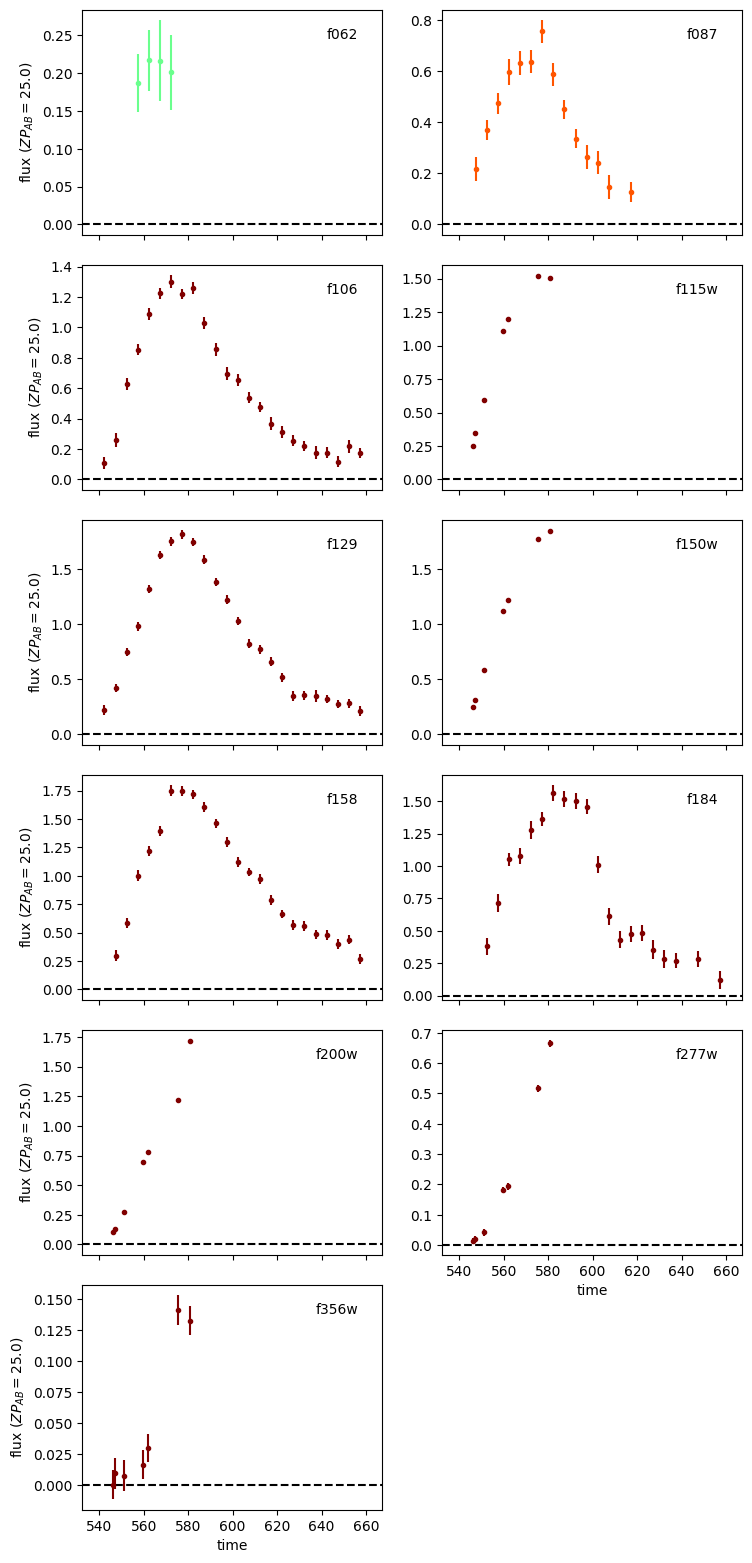

snia 0 {'z': 0.694421168842436, 't0': 1604.9850576886827, 'hostebv': 0.09806506753911703, 'hostr_v': 2.3382733292872517, 'M_peak_approx': -19.479456128507138, 'absmag_band_used': 'bessellb', 'model': <sncosmo.models.Model object at 0x7fd5e80997b0>}
    band      flux   fluxerr    zp zpsys         time        mag    magerr  \
0   F184 -0.038252  0.064083  25.0    ab  1574.985058        NaN       NaN   
1   F062  0.252253  0.047392  25.0    ab  1579.985058  26.495407  0.203982   
2   F087  0.367819  0.041707  25.0    ab  1579.985058  26.085915  0.123113   
3   F106  0.305348  0.032175  25.0    ab  1579.985058  26.288011  0.114404   
4   F129  0.249314  0.036951  25.0    ab  1579.985058  26.508135  0.160920   
5   F158  0.291376  0.042978  25.0    ab  1579.985058  26.338866  0.160148   
6   F184  0.273101  0.064430  25.0    ab  1579.985058  26.409191  0.256149   
7   F062  0.723111  0.042083  25.0    ab  1584.985058  25.351988  0.063187   
8   F087  0.789475  0.043700  25.0    ab  1584.98

In [107]:
# ============================================================
# SMALL TEST RUN
# ============================================================
test_n = 12
n_snia, n_sn2, n_snibc = counts_for_total(test_n)
print("Test split:", n_snia, n_sn2, n_snibc)

preview = []

uid = 0
for sn_type, n_this in [("snia", n_snia), ("sn2", n_sn2), ("snibc", n_snibc)]:
    for _ in range(n_this):
        #try:
        
        res = generate_single_sn(sn_type, uid)
        try:
            df, meta = res
        except:
            continue
        #except:
        #    continue
        print(sn_type,meta)
        sncosmo.plot_lc(Table.from_pandas(df))
        plt.show()
        preview.append((sn_type, uid, df, meta))
        uid += 1

for sn_type, uid, df, meta in preview[:3]:
    print("=" * 80)
    print(sn_type, uid, meta)
    print(df.head(12))
    print("N rows:", len(df))

In [111]:
def generate_large_sample_resumable(
    n_total=N_LIGHTCURVES,
    chunk_size=CHUNK_SIZE,
    output_root=OUTPUT_ROOT,
    shuffle_types=True,
    overwrite_existing=False,
):
    output_root.mkdir(parents=True, exist_ok=True)
    chunk_dir = output_root / "chunks"
    chunk_dir.mkdir(parents=True, exist_ok=True)

    type_sequence = build_type_sequence(n_total, shuffle=shuffle_types)
    n_chunks = math.ceil(n_total / chunk_size)

    print(f"Generating {n_total:,} total light curves")
    print(f"Chunk size: {chunk_size:,}")
    print(f"Number of chunks: {n_chunks:,}")

    all_manifest_paths = []

    for chunk_index in range(n_chunks):
        tar_path = chunk_dir / f"lightcurves_chunk_{chunk_index:05d}.tar.gz"
        manifest_path = chunk_dir / f"manifest_chunk_{chunk_index:05d}.csv"

        if (not overwrite_existing) and tar_path.exists() and manifest_path.exists():
            print(f"Skipping existing chunk {chunk_index:05d}")
            all_manifest_paths.append(manifest_path)
            continue

        start = chunk_index * chunk_size
        stop = min((chunk_index + 1) * chunk_size, n_total)

        chunk_sn_types = [
            (global_id, type_sequence[global_id])
            for global_id in range(start, stop)
        ]

        _ = generate_chunk_tarball(
            chunk_index=chunk_index,
            sn_types=chunk_sn_types,
            output_root=output_root,
        )

        all_manifest_paths.append(manifest_path)

    master_manifest = pd.concat(
        [pd.read_csv(p) for p in all_manifest_paths if p.exists()],
        ignore_index=True
    )

    master_manifest_path = output_root / "master_manifest.csv"
    master_manifest.to_csv(master_manifest_path, index=False)

    print(f"\nDone.")
    print(f"Master manifest written to: {master_manifest_path}")

    success_mask = master_manifest["tar_member"].notna()
    print(f"Successful light curves: {success_mask.sum():,}")
    print(f"Failed light curves: {(~success_mask).sum():,}")

    return master_manifest

def merge_chunk_tarballs(
    output_root=OUTPUT_ROOT,
    merged_name="all_lightcurves_merged.tar.gz",
    compresslevel=COMPRESSLEVEL,
):
    """
    Merge all per-chunk tarballs into one big tar.gz.
    This rewrites all files, so it can take a while.
    """
    chunk_dir = output_root / "chunks"
    chunk_tars = sorted(chunk_dir.glob("lightcurves_chunk_*.tar.gz"))

    merged_path = output_root / merged_name
    print(f"Merging {len(chunk_tars)} tarballs into {merged_path}")

    with tarfile.open(merged_path, mode="w:gz", compresslevel=compresslevel) as out_tar:
        for chunk_tar_path in chunk_tars:
            print(f"  adding {chunk_tar_path.name}")
            with tarfile.open(chunk_tar_path, mode="r:gz") as in_tar:
                for member in in_tar.getmembers():
                    if not member.isfile():
                        continue
                    fobj = in_tar.extractfile(member)
                    if fobj is None:
                        continue
                    data = fobj.read()
                    info = tarfile.TarInfo(name=f"{chunk_tar_path.stem}/{member.name}")
                    info.size = len(data)
                    out_tar.addfile(info, io.BytesIO(data))

    print(f"Done: {merged_path}")
    return merged_path

In [112]:
master_manifest = generate_large_sample_resumable(
    n_total=100,
    chunk_size=10,
    output_root=OUTPUT_ROOT,
    shuffle_types=True,
    overwrite_existing=False,
)

Generating 100 total light curves
Chunk size: 10
Number of chunks: 10
Chunk 00000 done | success=10 fail=0 | time=0.0 min | roman_jwst_sim/chunks/lightcurves_chunk_00000.tar.gz
Chunk 00001 done | success=10 fail=0 | time=0.0 min | roman_jwst_sim/chunks/lightcurves_chunk_00001.tar.gz
Chunk 00002 done | success=10 fail=0 | time=0.0 min | roman_jwst_sim/chunks/lightcurves_chunk_00002.tar.gz
Chunk 00003 done | success=10 fail=0 | time=0.0 min | roman_jwst_sim/chunks/lightcurves_chunk_00003.tar.gz
Chunk 00004 done | success=9 fail=1 | time=0.0 min | roman_jwst_sim/chunks/lightcurves_chunk_00004.tar.gz
Chunk 00005 done | success=10 fail=0 | time=0.0 min | roman_jwst_sim/chunks/lightcurves_chunk_00005.tar.gz
Chunk 00006 done | success=10 fail=0 | time=0.0 min | roman_jwst_sim/chunks/lightcurves_chunk_00006.tar.gz
Chunk 00007 done | success=10 fail=0 | time=0.0 min | roman_jwst_sim/chunks/lightcurves_chunk_00007.tar.gz
Chunk 00008 done | success=10 fail=0 | time=0.0 min | roman_jwst_sim/chunks